In [1]:
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa.display
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def create_melspectrogram(df, segmented_dir, all_categories, n_mels=128):
    segmented_dir = Path(segmented_dir)
    melspectrogram_list = []
    labels = []

    for index, f in tqdm(df.iterrows()):
        for file in segmented_dir.glob(f'{Path(f.fname).stem}_*.wav'):
            y, sr = librosa.load(file, sr=None)
            melspectrogram = librosa.feature.melspectrogram(y=y, 
                                                      sr=sr, 
                                                      n_mels=n_mels, 
                                                      fmax=sr/2)
            melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
            melspectrogram_list.append(melspectrogram_db)
            labels.append(f.label)
            
    X = np.array(melspectrogram_list)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    label_encoder.fit(all_categories)
    y = label_encoder.transform(labels)

    return X, y

Load train/test DataFrame

In [3]:
train_csv_path = 'kaggle_meta/train_post_competition.csv'
train_df = pd.read_csv(train_csv_path)

In [4]:
# musical_instruments = [
#     'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 'Knock',
#     'Gunshot_or_gunfire', 'Clarinet', 'Computer_keyboard',
#     'Keys_jangling', 'Snare_drum', 'Writing', 'Laughter', 'Tearing',
#     'Fart', 'Oboe', 'Flute', 'Cough', 'Telephone', 'Bark', 'Chime',
#     'Bass_drum', 'Bus', 'Squeak', 'Scissors', 'Harmonica', 'Gong',
#     'Microwave_oven', 'Burping_or_eructation', 'Double_bass',
#     'Shatter', 'Fireworks', 'Tambourine', 'Cowbell', 'Electric_piano',
#     'Meow', 'Drawer_open_or_close', 'Applause', 'Acoustic_guitar',
#     'Violin_or_fiddle', 'Finger_snapping'
# ]

musical_instruments = [
    'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 
    'Clarinet', 'Oboe', 'Flute', 'Bass_drum', 'Double_bass',
    'Tambourine', 'Cowbell', 'Electric_piano', 'Harmonica', 
    'Acoustic_guitar', 'Violin_or_fiddle'
]

train_df = train_df[train_df['label'].isin(musical_instruments)]

In [5]:
train_df = train_df[train_df['fname'].apply(lambda x: os.path.exists(os.path.join('kaggle_data', x)))]
train_df = train_df[train_df['manually_verified'] == 1]
train_df = train_df.reset_index(drop=True)

Import data for model

In [6]:
X, y = create_melspectrogram(train_df, 'kaggle_segmented', musical_instruments)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

1847it [00:36, 50.08it/s]


Plot mel spectrogram

In [7]:
def plot_melspectrogram(X, i=0):
    melspectrogram_sample = X[i, :, :, 0]
    librosa.display.specshow(melspectrogram_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    plt.show()

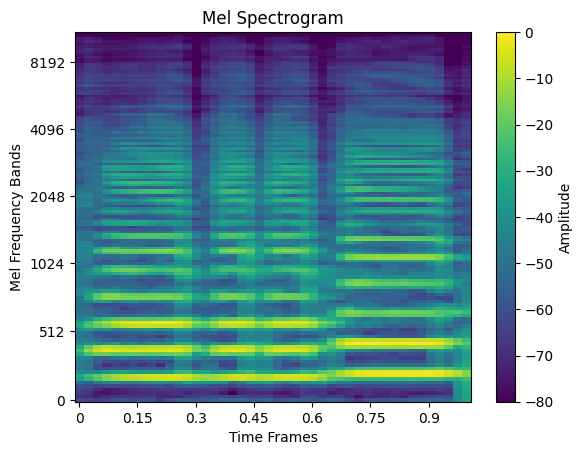

In [8]:
plot_melspectrogram(X)

CNN model

In [9]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X.shape[1], X.shape[2], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'])

c:\Users\grzes\anaconda3\envs\audio\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train CNN

In [10]:
early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = cnn.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)

Epoch 1/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.1629 - loss: 2.5050 - val_accuracy: 0.1431 - val_loss: 2.6102
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.3586 - loss: 1.7722 - val_accuracy: 0.2770 - val_loss: 2.2334
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.4966 - loss: 1.3895 - val_accuracy: 0.2138 - val_loss: 3.3765
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.5412 - loss: 1.2102 - val_accuracy: 0.1256 - val_loss: 6.3132
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.5847 - loss: 1.0903 - val_accuracy: 0.5399 - val_loss: 1.2927
Epoch 6/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.6169 - loss: 0.9301 - val_accuracy: 0.5316 - val_loss: 1.3953
Epoch 7/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.6555 - loss: 0.8537 - val_accuracy: 0.4459 - val_loss: 1.7377
Epoch 8/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.6508 - loss: 0.9295 - 

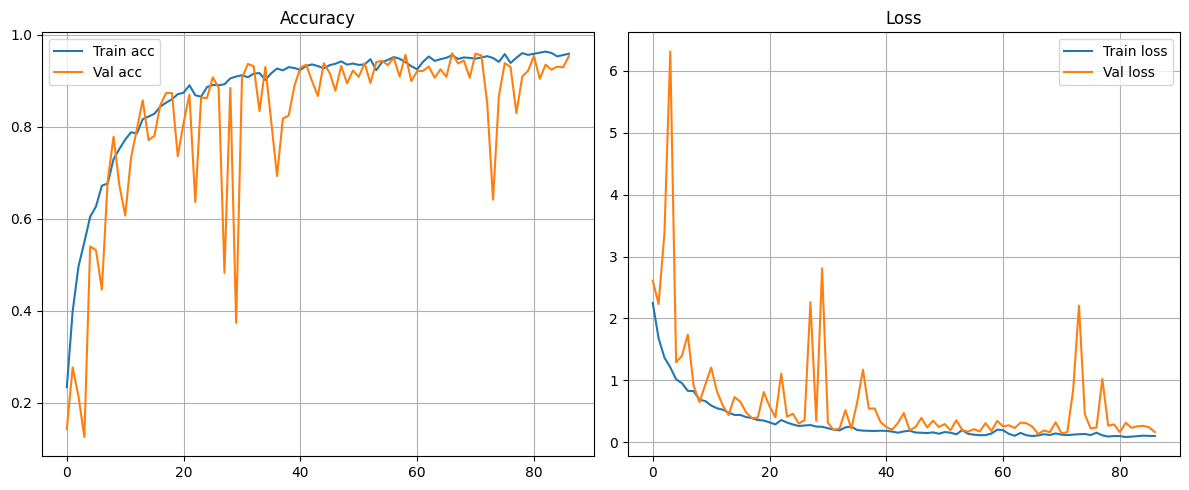

In [11]:
# with open("kaggle_cnn_melspectogram_history.pkl", "wb") as f:
#     pickle.dump(history.history, f)
    
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
# plt.savefig("kaggle_cnn_melspectogram_training_curves.png")
plt.show()

Evaluate CNN

In [ ]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = [musical_instruments[i] for i in y_pred]
y_test_labels = [musical_instruments[i] for i in y_test]

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

# output_file = 'cnn_melspectrogram_evaluation.txt'

# with open(output_file, 'w') as file:
#     file.write(f'Accuracy: {accuracy}\n')
#     file.write('\nClassification Report:\n')
#     file.write(class_report)

# best .94

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy: 0.948069241011984

Classification Report:
                   precision    recall  f1-score   support

 Acoustic_guitar       0.97      0.95      0.96        98
       Bass_drum       0.76      0.87      0.81        15
           Cello       0.95      0.95      0.95        21
        Clarinet       0.91      0.84      0.87        37
         Cowbell       0.91      0.97      0.94        63
     Double_bass       0.93      0.99      0.96        91
  Electric_piano       0.97      0.94      0.96       322
           Flute       0.95      0.98      0.96       167
    Glockenspiel       0.94      0.97      0.95       151
       Harmonica       0.96      0.93      0.95        28
          Hi-hat       0.95      0.87      0.91        71
            Oboe       0.96      0.91      0.93        95
       Saxophone       0.79      0.94      0.86        16
      Tambourine       0.96      1.00      0.98        23
         Trumpet       0.90      0.9

Save CNN

In [13]:
# cnn.save('cnn_melspectrogram_model.h5')